In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error 

In [3]:
data = {
    'size_sqft': [500, 750, 1000, 1200, 1500, 
                  1800, 2000, 2500, 3000, 3500,
                  4000, 4500, 5000, 5500, 6000],
    'bedrooms':  [1, 2, 2, 3, 3, 
                  3, 4, 4, 5, 5,
                  6, 6, 7, 7, 8],
    'location':  [1, 1, 2, 2, 3, 
                  3, 3, 4, 4, 5,
                  5, 5, 6, 6, 7],
    'price_lakh':[25, 35, 55, 65, 85, 
                  100, 115, 145, 180, 210,
                  245, 280, 320, 360, 400]
}

df = pd.DataFrame(data)
print(df)

    size_sqft  bedrooms  location  price_lakh
0         500         1         1          25
1         750         2         1          35
2        1000         2         2          55
3        1200         3         2          65
4        1500         3         3          85
5        1800         3         3         100
6        2000         4         3         115
7        2500         4         4         145
8        3000         5         4         180
9        3500         5         5         210
10       4000         6         5         245
11       4500         6         5         280
12       5000         7         6         320
13       5500         7         6         360
14       6000         8         7         400


In [4]:
X = df[['size_sqft', 'bedrooms', 'location']]
y = df['price_lakh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("Training set size : ", len(X_train))
print("Testing set size : ", len(X_test))


Training set size :  12
Testing set size :  3


In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")
print(f"Model Coefficients: {model.coef_[0]} x size sqft , {model.coef_[1]} x bedrooms , {model.coef_[2]} x location , + {model.intercept_}")  # Coefficients for size_sqft, bedrooms, location

Model trained successfully.
Model Coefficients: 0.08021505376344074 x size sqft , -6.291566361739638 x bedrooms , -4.773030011234111 x location , + -6.92180227892797


In [6]:
y_pred = model.predict(X_test)

print("Predicted prices for test set: ", y_pred)


Predicted prices for test set:  [218.50790403 292.43139143  22.12112823]


In [7]:
print("Actual prices:   ", y_test.values)
print("Predicted prices:", y_pred.round(1))

Actual prices:    [210 280  25]
Predicted prices: [218.5 292.4  22.1]


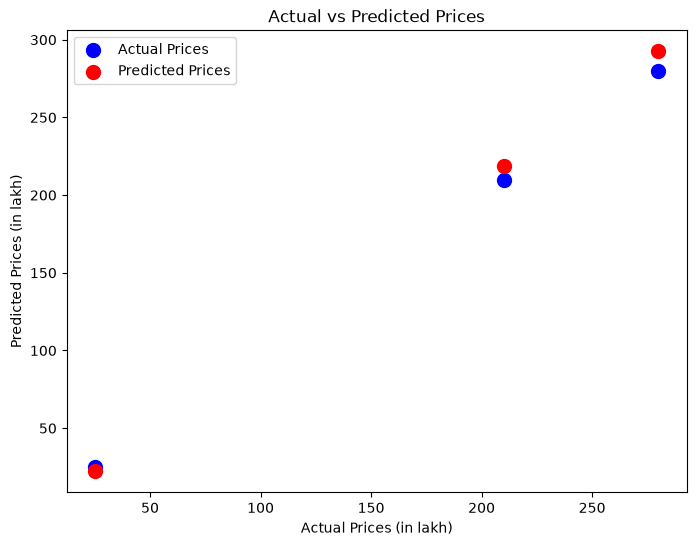

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test, color='blue', label='Actual Prices', s=100)
plt.scatter(y_test, y_pred, color='red', label='Predicted Prices', s=100)
plt.xlabel("Actual Prices (in lakh)")
plt.ylabel("Predicted Prices (in lakh)")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.show()


In [9]:
farq = y_test.values - y_pred
print("Farq (Actual - Predicted): ", farq.round(1))
squared_errors = farq ** 2
print("Squared Errors: ", squared_errors.round(1))
mse = np.mean(squared_errors)
print(f"Mean Squared Error (MSE): {mse:.2f} lakh^2")
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} lakh")
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# print(f"RMSE: {rmse:.2f} lakh")
# print(f"Matlab average {rmse:.1f} lakh ka farq hai prediction mein")

Farq (Actual - Predicted):  [ -8.5 -12.4   2.9]
Squared Errors:  [ 72.4 154.5   8.3]
Mean Squared Error (MSE): 78.40 lakh^2
Root Mean Squared Error (RMSE): 8.85 lakh


In [10]:
naya_ghar = pd.DataFrame({
    'size_sqft': [2200],
    'bedrooms': [4],
    'location': [3]
})

predicted_price = model.predict(naya_ghar)
print(f"2200 sqft, 4 bedroom, location 3 ka price: Rs. {predicted_price[0]:.1f} lakh")

2200 sqft, 4 bedroom, location 3 ka price: Rs. 130.1 lakh


In [11]:
aik_naya_ghar = pd.DataFrame({
    'size_sqft': [3500],
    'bedrooms': [5],
    'location': [4]
})

predicted_price = model.predict(aik_naya_ghar)
print(f"3500 sqft, 5 bedroom, location 4 ka price: Rs. {predicted_price[0]:.1f} lakh")

3500 sqft, 5 bedroom, location 4 ka price: Rs. 223.3 lakh
